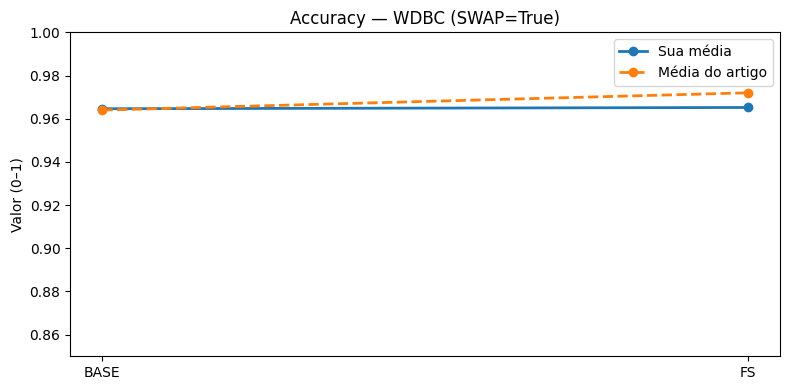

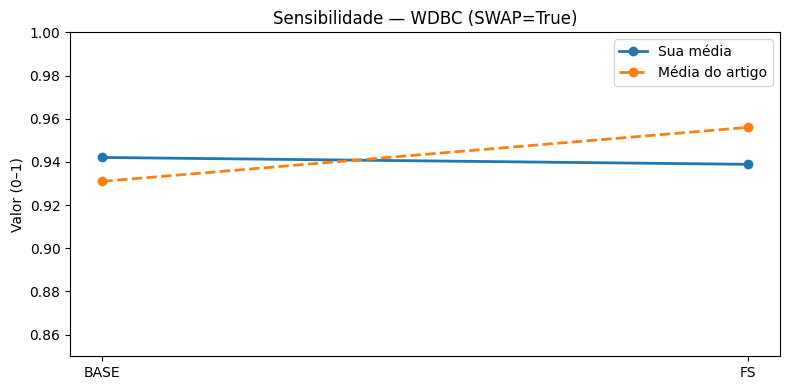

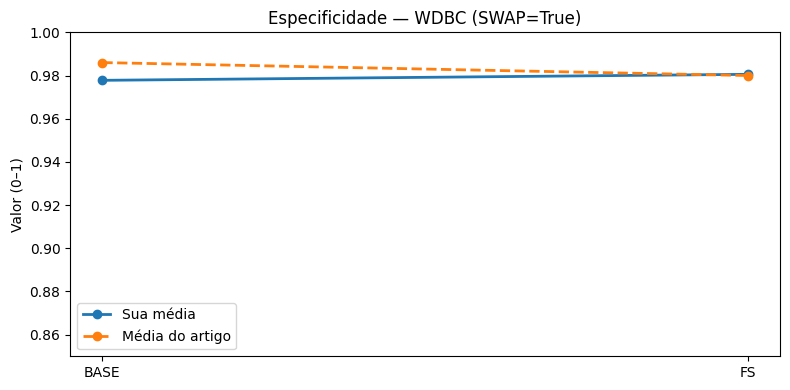

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== ajuste aqui =====
OUTDIR = r".\final_jobs1"
SWAP_SENS_SPEC = True  # True se quiser inverter sens<->spec (convenção de classe positiva)
# =======================

# Valores do artigo (WDBC, Tabela 5) para PSO/PS-classifier
ART_BASE = {"accuracy": 0.964, "sensitivity": 0.986, "specificity": 0.931}
ART_FS   = {"accuracy": 0.972, "sensitivity": 0.980, "specificity": 0.956}

def norm(v):
    return v/100.0 if v > 1 else v

ART_BASE = {k: norm(v) for k, v in ART_BASE.items()}
ART_FS   = {k: norm(v) for k, v in ART_FS.items()}

if SWAP_SENS_SPEC:
    ART_BASE["sensitivity"], ART_BASE["specificity"] = ART_BASE["specificity"], ART_BASE["sensitivity"]
    ART_FS["sensitivity"], ART_FS["specificity"]     = ART_FS["specificity"], ART_FS["sensitivity"]

df = pd.read_csv(f"{OUTDIR}\\wdbc_results_per_repeat.csv")

# médias dos seus resultados
MY_BASE = {
    "accuracy": df["base_accuracy"].mean(),
    "sensitivity": df["base_sensitivity"].mean(),
    "specificity": df["base_specificity"].mean(),
}
MY_FS = {
    "accuracy": df["fs_accuracy"].mean(),
    "sensitivity": df["fs_sensitivity"].mean(),
    "specificity": df["fs_specificity"].mean(),
}

plots = [
    ("accuracy", "Accuracy"),
    ("sensitivity", "Sensibilidade"),
    ("specificity", "Especificidade"),
]

for metric, title in plots:
    plt.figure(figsize=(8, 4))

    xs = ["BASE", "FS"]
    my_vals = [MY_BASE[metric], MY_FS[metric]]
    art_vals = [ART_BASE[metric], ART_FS[metric]]

    plt.plot(xs, my_vals, marker="o", linewidth=2, label="Média própria")
    plt.plot(xs, art_vals, marker="o", linestyle="--", linewidth=2, label="Média do artigo")

    plt.ylim(0.85, 1.0)
    plt.title(f"{title} — WDBC")
    plt.ylabel("Valor (0–1)")
    plt.legend()
    plt.tight_layout()
    plt.show()
